**IMPORTANTE: esta análise foi feita com a versão incompleta (Dados\beta\ ) do conjunto de dados.**

diferentes taxas de acerto pros comentarios filhos
DISCORDAR pode significar muitas coisas, cuidado

features: rotulo anterior: entrar ou não

começar fazendo por simplicidade: rotulo anterior foi dado (gabarito), depois ir pra tabela
segundo problema: class hierarquica acumularia mais erros ainda. Talvez seria melhor fazer por 3 classes (concroda, discorda, neutro)

Abordagem:
Usar LLMs com embeddings e utilizar algoritmos de classificação tradicionais.

In [1]:
# imports
import pandas as pd # manipulação do dataset
import matplotlib.pyplot as plt 
import seaborn as sns   # visualização dataset
import networkx as nx   # grafos
import pygraphviz as pgv    # visualização de grafos

# Análise Exploratória do dataset bruto

In [2]:
# importação do dataset de treinamento
df = pd.read_csv('Dados/aborto-consolidated-parent-based_treinamento.tsv', sep='\t', decimal = ',', encoding = 'UTF-8')
print(df.columns)
df.tail()

Index(['target_id', 'target_message', 'id', 'parent_id', 'author',
       'parent_name', 'parent_message', 'message', 'parent_label',
       'target_parent_message', 'target_and_message', 'label'],
      dtype='object')


,target_id,target_message,id,parent_id,author,parent_name,parent_message,message,parent_label,target_parent_message,target_and_message,label
613,50,"Eu entendo que, como budista, acredito que a v...",12,11,Mr._William_Grant,Willie_Ross,">a vida é sagrada, seja ela no inicio, ou após...","Eu compreendo totalmente seus argumentos, poré...",Concorda,"Eu entendo que, como budista, acredito que a v...","Eu entendo que, como budista, acredito que a v...",Discorda
614,50,"Eu entendo que, como budista, acredito que a v...",13,12,Willie_Ross,Mr._William_Grant,"Eu compreendo totalmente seus argumentos, poré...","Eu dei a minha resposta sobre o ""aborto ser ac...",Discorda,"Eu entendo que, como budista, acredito que a v...","Eu entendo que, como budista, acredito que a v...",Concorda
615,51,"Se você perguntar que o aborto é aceitável, a ...",Alvo,Alvo,Alvo,Alvo,Alvo,"Se você perguntar que o aborto é aceitável, a ...",Alvo da conversa,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Alvo da conversa
616,51,"Se você perguntar que o aborto é aceitável, a ...",1,NaN,Jennifer_Brooks,Raiz,NaN,Não.,NaN,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Comentário Original
617,51,"Se você perguntar que o aborto é aceitável, a ...",2,1,Danielle_Cannon,Jennifer_Brooks,Não.,Por quê?,Comentário Original,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Pede Informações


Descrição das colunas:
- 'id', 'message', 'label', 'author' -> comentário atual avaliado
- 'target_id' -> id relativo ao coment original. Os demais ids em colunas são de comentários em relação a este.
- 'target_message' -> Alvo; mensagem que avalia-se o posicionamento.
- 'parent_name', 'parent_message', 'parent_label' -> comentário anterior, cujo atual responde
- 'target_and_message' -> mensagem alvo # comentário atual
- 'target_parent_message' -> mensagem alvo # parent # comentário atual

(*) Linha com id "Alvo" = descrição feita manualmente que sitetiza o pensamento do comentário Alvo.

### Labels

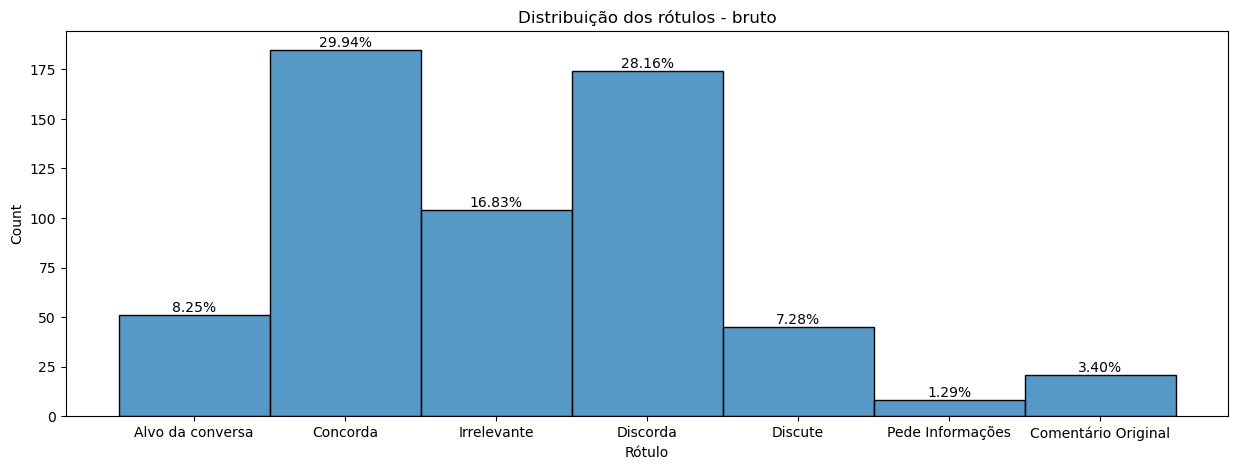

In [85]:
# Distribuição dos rótulos
plt.figure(figsize=(15, 5))
sns.histplot(x='label', data=df)
plt.title('Distribuição dos rótulos - bruto')
plt.xlabel('Rótulo')

# colocar label nas "barras" como porcentagem
total = len(df)
for p in plt.gca().patches:
    percentage = f'{p.get_height() / total:.2%}'
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), percentage, ha='center', va='bottom')

Utilizarei as classes: Concorda, Discorda, Neutro (Discute, Irrelevante ou Pede informações).

Text(0.5, 1.0, 'Distribuição dos rótulos')

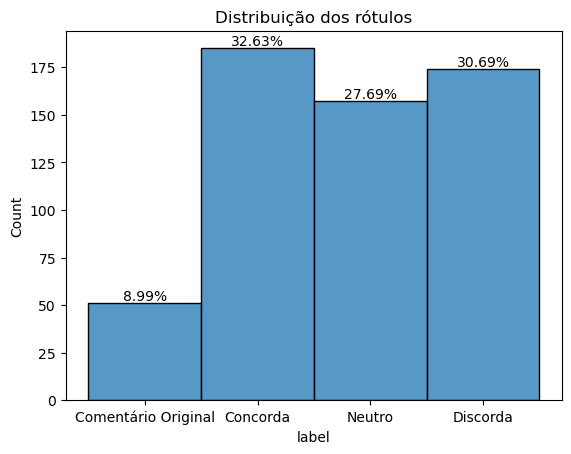

In [ ]:
df_n = df.copy()

# desconsiderar linhas de "Alvo" para análise de distribuição (contem apenas mensagem de apoio)
df_n = df_n[df_n['id'] != 'Alvo']

# juntar labels "Neutro"
df_n['label'] = df_n['label'].replace('Discute', 'Neutro').replace('Pede Informações', 'Neutro').replace('Irrelevante', 'Neutro')

sns.histplot(x='label', data=df_n)
# colocar label nas "barras" como porcentagem
total = len(df_n)
for p in plt.gca().patches:
    percentage = f'{p.get_height() / total:.2%}'
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), percentage, ha='center', va='bottom')
plt.title('Distribuição dos rótulos')

# nota: o gráfico gerado já está com os rótulos "Comentário Original" corrigidos na seção posterior.

### Valores nulos

In [31]:
# checagem de valores nulos
print(df.isnull().sum())

target_id                  0
target_message             0
id                         0
parent_id                 51
author                     0
parent_name                0
parent_message            32
message                    0
parent_label             116
target_parent_message      0
target_and_message         0
label                     30
dtype: int64


In [ ]:
df['target_id'].unique()  # id do postagem original (alvo)
# mesma quantidade de parent_id nulos

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51])

In [ ]:
# 30 linhas sem label
sem_label = df[df['label'].isnull()]

# são referentes ao comentário original (id = 1)
print(len(sem_label[sem_label['id'] == '1']))
# quantas linhas com id = 1?
print(len(df[df['id'] == '1']))

# Problema: apenas metade das linhas consideram a label do (id = 1) como "Comentário Original". Devemos corrigir isso.
df_n.loc[df_n['id'] == '1', 'label'] = 'Comentário Original'

0
51


In [45]:
# Linhas onde parent_label é nulo mas parent_message não é
sem_parent_label = df[df['parent_label'].isnull() & df['parent_message'].notnull()]
# são filhos dos comentarios originais, que não possuem label.

### Visualização em Grafo

In [3]:
def criar_grafo(df):
    # Crie um grafo direcionado
    G = nx.DiGraph()

    # Adicione nós (comentários)
    for idx, row in df.iterrows():
        G.add_node(row['id'])

    # Adicione arestas de parent (resposta)
    for idx, row in df.iterrows():
        if pd.notnull(row['parent_id']):
            G.add_edge(row['parent_id'], row['id'], relation='parent')

    # Adicione arestas de target (alvo)
    """ for idx, row in df.iterrows():
        if pd.notnull(row['target_id']):
            G.add_edge(row['target_id'], row['id'], relation='target') """

    # Visualização simples (atenção: para muitos nós pode ficar poluído)
    """ plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
    plt.show() """

    return G

G = criar_grafo(df)

In [4]:
# Visualização hierárquica (top-down)
def visualizar_grafo(G, titulo='Grafo de comentários'):
    plt.figure(figsize=(12, 8))
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')  # ou: nx.nx_pydot.graphviz_layout(G, prog='dot')
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
    plt.title(titulo)  # Set the title here
    plt.show()

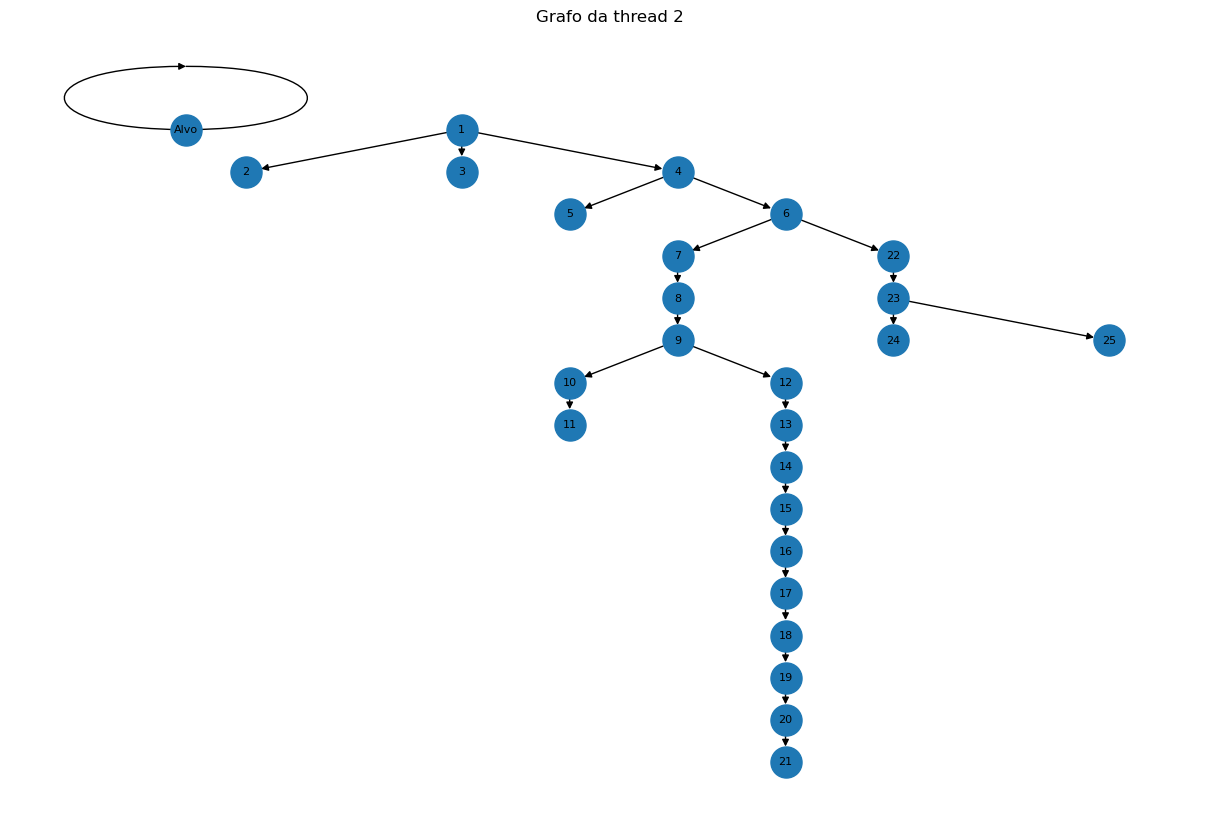

In [5]:
# df de uma thread específica
thread_id = 2
df_postagem = df[df['target_id'] == 2]  # target_id é o id da thread. Os demais ids em colunas são de comentários em relação a esta.

G_postagem = criar_grafo(df_postagem)
visualizar_grafo(G_postagem, titulo='Grafo da thread ' + str(thread_id))

## Conclusões

Para que o dataset atenda a finalidade do projeto:
- Em relação aos comentários "target" e "parent", considerarei apenas o id; a mensagem e (posteriormente) a label serão consideradas por meio do acesso à linha destes.
- Aprox. metade dass linhas de comentários originais, no dataset bruto, não têm label. Isso quebrará a lógica da classificação que toma como feature (além das embeddings) a label do comentário pai (parent). No pré processamento, vou defini-las como ("Comentário Original" ou) "Concordo", pois são elas que ditarão a mensagem alvo.